In [1]:
# 1. 导入模块、读取配置和路径
import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

_base = Path('/home/intern_fjq_2026').resolve()
_current = Path.cwd().resolve()
_candidates = [
    _base / 'Projects' / 'chinese-wwm-roberta',
    _base.parent / 'intern_fjq_2026' / 'Projects' / 'chinese-wwm-roberta',
    _current,
    _current.parent,
]
ROOT = next((path for path in _candidates if (path / 'src').is_dir()), None)
assert ROOT is not None, 'Repository root was not found'
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.activation_rank import (
    finalize_activation_rank_run,
    load_activation_rank_config,
    plot_rank_curves,
    plot_rank_heatmap,
    preflight_activation_rank,
    run_pilot_stage,
    run_rank_analysis_stage,
    run_rank_shards_stage,
    run_sample_stage,
    run_wo_mechanism_stage,
    validate_pilot_outputs,
    validate_rank_analysis_outputs,
    validate_wo_mechanism_outputs,
)

CONFIG_PATH = ROOT / 'configs' / 'activation_rank.yaml'
config = load_activation_rank_config(CONFIG_PATH)
RUN_DIR = Path(config['output']['run_directory']).expanduser().resolve()
display({'config': str(CONFIG_PATH), 'run_directory': str(RUN_DIR)})

{'config': '/home/intern_fjq_2026/Projects/chinese-wwm-roberta/configs/activation_rank.yaml',
 'run_directory': '/home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/checkpoint_activation_rank/runs/financial_reports_v2'}

In [2]:
# 2. 服务器、GPU、磁盘、checkpoint与文本preflight
preflight = preflight_activation_rank(config)
display(preflight)
assert preflight['status'].eq('ok').all(), preflight

,check,status,detail
0,text,ok,/home/intern_fjq_2026/Projects/chinese-wwm-rob...
1,checkpoint,ok,/home/intern_fjq_2026/Projects/chinese-wwm-rob...
2,tokenizer,ok,/home/intern_fjq_2026/Projects/chinese-wwm-rob...
3,disk_budget,ok,"{""estimated_peak"": 6442450944, ""free"": 6259870..."
4,cpu_runtime,ok,"{""configured_threads"": 8, ""effective_threads"":..."
5,gpu_runtime,ok,"{""requested_device"": ""cuda:1"", ""cuda"": true, ""..."


In [3]:
# 3. 构建或严格复用sample manifest
sample_dir = run_sample_stage(config)
sample_manifest = pd.read_parquet(sample_dir / 'sample_manifest.parquet')
display(sample_manifest.head())
display(sample_manifest.groupby('shard')['token_count'].agg(['count', 'sum']))

,sample_row,source_row,report_id,text_sha256,stable_order,shard,token_count,is_unique_text
0,0,346841,392db3cbaf986062aef667b53d6994da444f439fd98453...,468d24aa18e6dab2482f63abe663851ef7b60279373433...,8991769536629,5,4,True
1,1,434587,c177b5ba77aa9a09b3c23a9922ffde040348deafe9d8ea...,0d1f506e308adb49f8a189f231bbe2754cfa821e4ee3bc...,38137858979464,0,510,True
2,2,218975,aa1326815aa7290a446a0652d787aa1dffc90f590c8d4b...,7074ed77bd1921175bfdaf101fe72a978b1e2cb02eb6a4...,40860073821757,5,4,True
3,3,845838,aaf9db3452ece97636747d2fbf304041e7da5732e67d0b...,967792222fe09f4cf0c194313fa823b965d01f8afbe66e...,58351295589966,6,510,True
4,4,987663,f18291e784eb476780fa2ab47c35f60ee5c9c5f6a188b4...,e7f1fbe3bb6af2bc1545ac1a06ce2ca04488fd030f03f2...,66113139498634,2,510,True


,count,sum
shard,,
0,3499,1250032
1,3374,1250126
2,3424,1250242
3,3473,1250062
4,3401,1250460
5,3399,1250149
6,3381,1250012
7,3463,1250496


In [4]:
# 4. hooks、精度、batch size与吞吐pilot
pilot_dir = run_pilot_stage(config)
pilot_manifest = validate_pilot_outputs(pilot_dir)
display(pd.Series(pilot_manifest))
display(pd.read_parquet(pilot_dir / 'batch_benchmark.parquet'))
display(pd.read_parquet(pilot_dir / 'precision_metrics.parquet'))

/home/intern_fjq_2026/miniconda3/envs/nlp_fjq/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


schema_version                                        activation_rank_pilot_v2.0
checkpoint_sha256              b6de21972c150139d0407b8e8e92bed3db9f23f92a1c70...
tokenizer_sha256               53b05407adaa567cf2cb7b57a8d05b9ab399cbd40af55d...
text_source_sha256             f143f1070d1e83a5958f43c1b4b28f9f8ffed0688f47d8...
config_sha256                  53500234d64b9ab4bda96ccc11b90d08ae992832c4b569...
max_length                                                                   512
git_commit                              620b2218d8b0fe3d4f6670647f61f64790081674
activation_rank_code_sha256    b0a428a100907afa6b83344ead27eefc7c8034c4a2bb87...
run_fingerprint                e83a6cbd2031e300a467d96dccf8db02a39d0de1696b2b...
created_at                                                   2026-09-01T16:59:54
selected_compute_dtype                                                   float16
norm_calibration_dtype                                                   float16
pilot_valid_tokens          

,batch_size,status,peak_memory_bytes,total_memory_bytes,headroom_fraction,checksum,rows,valid_tokens,batches,seconds,valid_tokens_per_second,padding_ratio
0,64,ok,2741471232,85043904512,0.967764,5.042122e+05,128,44528,3,1.511432,29460.799405,0.032743
1,128,ok,5065426944,85043904512,0.940438,1.014196e+06,256,89484,3,1.920414,46596.195083,0.032904
2,256,ok,9710602240,85043904512,0.885817,2.041665e+06,512,179221,3,3.874831,46252.601342,0.033922
3,512,ok,19001609216,85043904512,0.776567,4.106788e+06,1024,362221,3,7.768827,46624.926415,0.033287


,dtype,rows,valid_tokens,batches,seconds,valid_tokens_per_second,padding_ratio,peak_memory_bytes,maximum_normalized_erank_difference,maximum_k99_difference,maximum_relative_spectrum_difference_above_1pct,passed
0,float32,1410,502928,3,10.301589,48820.429843,0.033218,19484496384,0.000000,0,0.000000,True
1,float16,1410,502928,3,5.042729,99733.299658,0.033218,9988630016,0.000165,1,0.002066,True
2,bfloat16,1410,502928,3,5.100709,98599.622476,0.033218,9988630016,0.001673,2,0.023174,False


In [ ]:
# 5. 运行缺失的rank shards；已验证分片自动跳过
# kernel重启或某一shard失败后，只需重跑cell 1与本cell。
try:
    moments_dir = run_rank_shards_stage(config)
except RuntimeError:
    audit_candidates = [RUN_DIR / 'moments' / 'norm_audit_5m.parquet', RUN_DIR / 'moments' / 'norm_audit.parquet']
    for audit_path in audit_candidates:
        if audit_path.is_file():
            display(pd.read_parquet(audit_path).sort_values(['blocking', 'position_passed', 'population', 'site'], ascending=[False, True, True, True]))
    raise
moments_manifest = json.loads((moments_dir / 'manifest.json').read_text(encoding='utf-8'))
display(pd.Series(moments_manifest))
display(pd.DataFrame(moments_manifest['norm_audit']['failed_blocking_positions']))
norm_audit = pd.read_parquet(moments_dir / 'norm_audit.parquet')
display(norm_audit.sort_values(['blocking', 'position_passed', 'population', 'site'], ascending=[False, True, True, True]))

In [ ]:
# 6. 合并moments、FP64特征分解与稳定性/坍缩分析
analysis_dir = run_rank_analysis_stage(config)
display(pd.Series(validate_rank_analysis_outputs(analysis_dir)))
rank_metrics = pd.read_parquet(analysis_dir / 'rank_metrics.parquet')
compression_metrics = pd.read_parquet(analysis_dir / 'compression_metrics.parquet')
display(rank_metrics)
display(compression_metrics)

schema_version                                     activation_rank_analysis_v2.0
checkpoint_sha256              b6de21972c150139d0407b8e8e92bed3db9f23f92a1c70...
tokenizer_sha256               53b05407adaa567cf2cb7b57a8d05b9ab399cbd40af55d...
text_source_sha256             f143f1070d1e83a5958f43c1b4b28f9f8ffed0688f47d8...
config_sha256                  53500234d64b9ab4bda96ccc11b90d08ae992832c4b569...
max_length                                                                   512
git_commit                              5a62e7be26739399b15b7defb6f9af34c81ecba3
activation_rank_code_sha256    b0a428a100907afa6b83344ead27eefc7c8034c4a2bb87...
run_fingerprint                a5f35485e42bcdc5d8d28286236b9b1b398e457eed93e1...
selected_compute_dtype                                                   float16
norm_calibration_dtype                                                   float16
selected_batch_size                                                          512
norm_thresholds_sha256      

,stream,site,kind,layer,count,effective_rank,normalized_effective_rank,stable_rank,k90_variance,k95_variance,k99_variance,directions_above_1pct_max,dimension
0,token_natural_filtered,residual_00,residual,0,10001579,596.498733,0.776691,45.388280,343,456,635,765,768
1,token_natural_filtered,residual_01,residual,1,10001579,593.941689,0.773362,35.890480,331,448,640,767,768
2,token_natural_filtered,residual_02,residual,2,10001579,608.881733,0.792815,28.284154,354,477,664,767,768
3,token_natural_filtered,residual_03,residual,3,10001579,618.536724,0.805386,26.222119,373,499,679,767,768
4,token_natural_filtered,residual_04,residual,4,10001579,613.473939,0.798794,25.142447,367,497,681,767,768
...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,token_unique_filtered,mlp_output_08,mlp_output,8,9979379,639.058750,0.832108,28.584081,405,520,684,768,768
241,token_unique_filtered,mlp_output_09,mlp_output,9,9979298,635.548671,0.827537,24.386715,399,516,682,768,768
242,token_unique_filtered,mlp_output_10,mlp_output,10,9979785,621.980650,0.809871,16.408499,374,495,674,768,768
243,token_unique_filtered,mlp_output_11,mlp_output,11,9979719,622.623741,0.810708,21.421042,381,500,673,768,768


,layer,ratio_erank_o_to_z,ratio_erank_o_to_z_ci_lower,ratio_erank_o_to_z_ci_upper,ratio_erank_o_to_mlp,ratio_erank_o_to_mlp_ci_lower,ratio_erank_o_to_mlp_ci_upper,ratio_erank_o_to_residual,ratio_erank_o_to_residual_ci_lower,ratio_erank_o_to_residual_ci_upper,evidence
0,1,0.696739,0.696573,0.696889,0.637088,0.636671,0.637442,0.633762,0.633300,0.634163,clear_collapse
1,2,0.737574,0.737494,0.737650,0.624082,0.623943,0.624210,0.634853,0.634632,0.635059,clear_collapse
2,3,0.752953,0.752876,0.753019,0.689520,0.689409,0.689639,0.705694,0.705552,0.705830,clear_collapse
3,4,0.744842,0.744737,0.744954,0.691791,0.691685,0.691901,0.712575,0.712352,0.712811,clear_collapse
4,5,0.780788,0.780692,0.780883,0.695512,0.695304,0.695735,0.710785,0.710583,0.710981,clear_collapse
5,6,0.770149,0.770099,0.770197,0.737244,0.737175,0.737333,0.766442,0.766315,0.766573,clear_collapse
6,7,0.779284,0.779251,0.779320,0.718510,0.718300,0.718713,0.747865,0.747701,0.748023,clear_collapse
7,8,0.833102,0.833005,0.833186,0.734125,0.733950,0.734283,0.764416,0.764291,0.764548,clear_collapse
8,9,0.777680,0.777595,0.777772,0.747352,0.747216,0.747521,0.769243,0.769088,0.769429,clear_collapse
9,10,0.793312,0.793058,0.793553,0.738282,0.737574,0.738902,0.742259,0.741556,0.742888,clear_collapse


In [ ]:
# 7. W^O协方差恒等式、方向分解与反事实机制分析
mechanism_dir = run_wo_mechanism_stage(config)
display(pd.Series(validate_wo_mechanism_outputs(mechanism_dir)))
display(pd.read_parquet(mechanism_dir / 'wo_summary.parquet'))
display(pd.read_parquet(mechanism_dir / 'wo_mechanism.parquet').head(24))

schema_version                                 activation_rank_wo_mechanism_v2.0
checkpoint_sha256              b6de21972c150139d0407b8e8e92bed3db9f23f92a1c70...
tokenizer_sha256               53b05407adaa567cf2cb7b57a8d05b9ab399cbd40af55d...
text_source_sha256             f143f1070d1e83a5958f43c1b4b28f9f8ffed0688f47d8...
config_sha256                  53500234d64b9ab4bda96ccc11b90d08ae992832c4b569...
max_length                                                                   512
git_commit                              5a62e7be26739399b15b7defb6f9af34c81ecba3
activation_rank_code_sha256    b0a428a100907afa6b83344ead27eefc7c8034c4a2bb87...
run_fingerprint                a5f35485e42bcdc5d8d28286236b9b1b398e457eed93e1...
selected_compute_dtype                                                   float16
norm_calibration_dtype                                                   float16
selected_batch_size                                                          512
norm_thresholds_sha256      

,layer,covariance_relative_frobenius_error,observed_learned_wo_effective_rank,observed_learned_wo_normalized_effective_rank,observed_learned_wo_k99_variance,polar_orthogonal_scaled_effective_rank,polar_orthogonal_scaled_normalized_effective_rank,polar_orthogonal_scaled_k99_variance,random_orthogonal_scaled_effective_rank,random_orthogonal_scaled_normalized_effective_rank,random_orthogonal_scaled_k99_variance,wo_only_isotropic_input_effective_rank,wo_only_isotropic_input_normalized_effective_rank,wo_only_isotropic_input_k99_variance,covariance_identity_tolerance,covariance_identity_passed
0,1,0.000216,376.563783,0.490317,363,540.582138,0.703883,571,540.582138,0.703883,571,574.900814,0.748569,562,0.005,True
1,2,0.000253,386.682899,0.503493,363,524.369522,0.682773,538,524.369522,0.682773,538,571.279495,0.743854,554,0.005,True
2,3,0.000261,436.549340,0.568424,431,579.805343,0.754955,617,579.805343,0.754955,617,582.022475,0.757842,557,0.005,True
3,4,0.000265,437.241383,0.569325,430,587.072931,0.764418,632,587.072931,0.764418,632,572.478791,0.745415,554,0.005,True
4,5,0.000304,435.695437,0.567312,428,558.132864,0.726735,609,558.132864,0.726735,609,573.124933,0.746256,551,0.005,True
5,6,0.000279,468.269372,0.609726,464,608.067998,0.791755,673,608.067998,0.791755,673,581.801080,0.757553,555,0.005,True
6,7,0.000265,459.558742,0.598384,456,589.706768,0.767847,634,589.706768,0.767847,634,596.939284,0.777265,566,0.005,True
7,8,0.000343,471.886559,0.614436,475,564.151006,0.734572,611,564.151006,0.734572,611,597.845947,0.778445,570,0.005,True
8,9,0.000281,475.088599,0.618605,483,611.117138,0.795725,682,611.117138,0.795725,682,600.116044,0.781401,576,0.005,True
9,10,0.000284,459.566002,0.598393,469,579.358224,0.754373,666,579.358224,0.754373,666,601.153587,0.782752,573,0.005,True


,layer,component,attention_output_eigenvalue,z_directional_variance,wo_scale_squared,factor_product
0,1,1,5.201999,1.373344,3.787833,5.202000
1,1,2,3.323629,0.811079,4.097830,3.323662
2,1,3,2.465813,0.670848,3.675646,2.465800
3,1,4,2.187486,0.693173,3.155753,2.187483
4,1,5,2.035882,0.617285,3.298157,2.035902
5,1,6,1.744595,0.457558,3.812909,1.744625
6,1,7,1.508239,0.454479,3.318661,1.508261
7,1,8,1.480698,0.408965,3.620657,1.480724
8,1,9,1.359016,0.381025,3.566752,1.359023
9,1,10,1.327363,0.385152,3.446330,1.327361


schema_version                                          activation_rank_run_v2.0
checkpoint_sha256              b6de21972c150139d0407b8e8e92bed3db9f23f92a1c70...
tokenizer_sha256               53b05407adaa567cf2cb7b57a8d05b9ab399cbd40af55d...
text_source_sha256             f143f1070d1e83a5958f43c1b4b28f9f8ffed0688f47d8...
config_sha256                  53500234d64b9ab4bda96ccc11b90d08ae992832c4b569...
max_length                                                                   512
git_commit                              5a62e7be26739399b15b7defb6f9af34c81ecba3
activation_rank_code_sha256    b0a428a100907afa6b83344ead27eefc7c8034c4a2bb87...
run_fingerprint                a5f35485e42bcdc5d8d28286236b9b1b398e457eed93e1...
selected_compute_dtype                                                   float16
norm_calibration_dtype                                                   float16
selected_batch_size                                                          512
norm_thresholds_sha256      

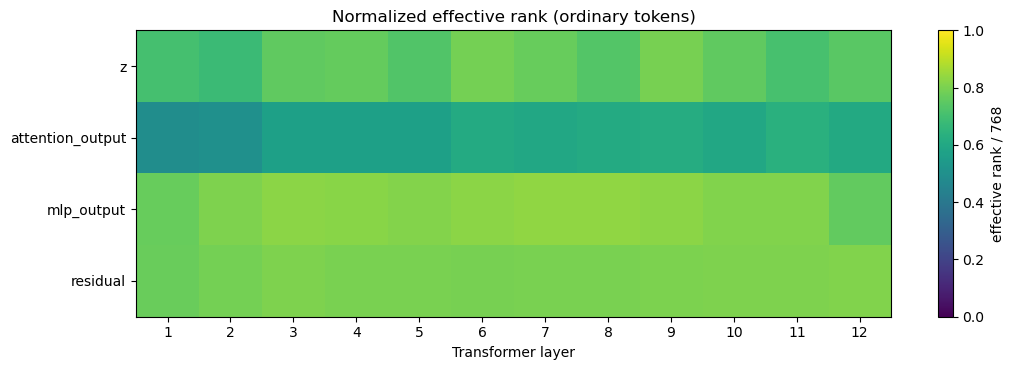

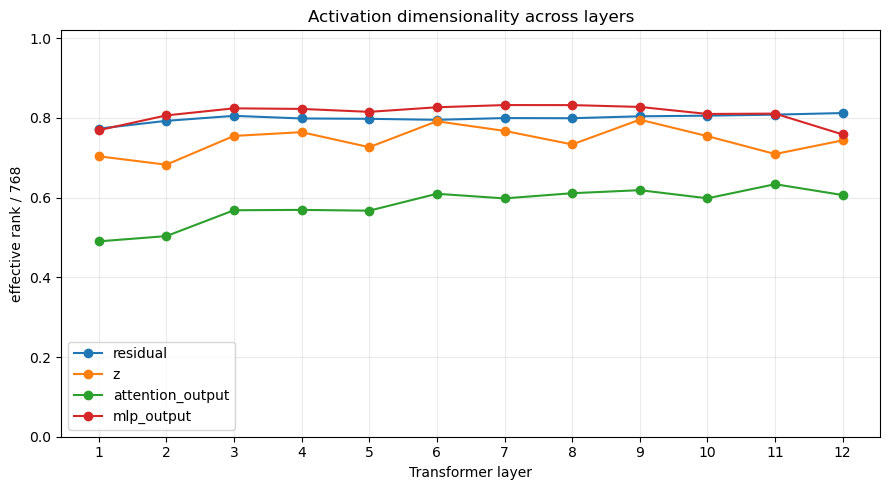

,layer,ratio_erank_o_to_z,ratio_erank_o_to_z_ci_lower,ratio_erank_o_to_z_ci_upper,ratio_erank_o_to_mlp,ratio_erank_o_to_mlp_ci_lower,ratio_erank_o_to_mlp_ci_upper,ratio_erank_o_to_residual,ratio_erank_o_to_residual_ci_lower,ratio_erank_o_to_residual_ci_upper,evidence
0,1,0.696739,0.696573,0.696889,0.637088,0.636671,0.637442,0.633762,0.633300,0.634163,clear_collapse
1,2,0.737574,0.737494,0.737650,0.624082,0.623943,0.624210,0.634853,0.634632,0.635059,clear_collapse
2,3,0.752953,0.752876,0.753019,0.689520,0.689409,0.689639,0.705694,0.705552,0.705830,clear_collapse
3,4,0.744842,0.744737,0.744954,0.691791,0.691685,0.691901,0.712575,0.712352,0.712811,clear_collapse
4,5,0.780788,0.780692,0.780883,0.695512,0.695304,0.695735,0.710785,0.710583,0.710981,clear_collapse
5,6,0.770149,0.770099,0.770197,0.737244,0.737175,0.737333,0.766442,0.766315,0.766573,clear_collapse
6,7,0.779284,0.779251,0.779320,0.718510,0.718300,0.718713,0.747865,0.747701,0.748023,clear_collapse
7,8,0.833102,0.833005,0.833186,0.734125,0.733950,0.734283,0.764416,0.764291,0.764548,clear_collapse
8,9,0.777680,0.777595,0.777772,0.747352,0.747216,0.747521,0.769243,0.769088,0.769429,clear_collapse
9,10,0.793312,0.793058,0.793553,0.738282,0.737574,0.738902,0.742259,0.741556,0.742888,clear_collapse


: 

In [ ]:
# 8. 图表、结论表与最终run manifest
completed_dir = finalize_activation_rank_run(config)
final_manifest = json.loads((completed_dir / 'manifest.json').read_text(encoding='utf-8'))
display(pd.Series(final_manifest))
display(plot_rank_heatmap(completed_dir / 'analysis'))
display(plot_rank_curves(completed_dir / 'analysis'))
display(pd.read_parquet(completed_dir / 'compression_metrics.parquet'))

,effective_rank,normalized_erank,k90,k95,k99,dirs_above_1pct,dimension
kind,,,,,,,
attention_output,446.4,0.6,198.6,279.8,442.9,655.2,768
mlp_output,623.2,0.8,378.7,495.1,668.0,763.9,768
residual,614.0,0.8,367.2,497.9,680.9,767.0,768
z,571.5,0.7,307.4,427.3,621.6,767.8,768


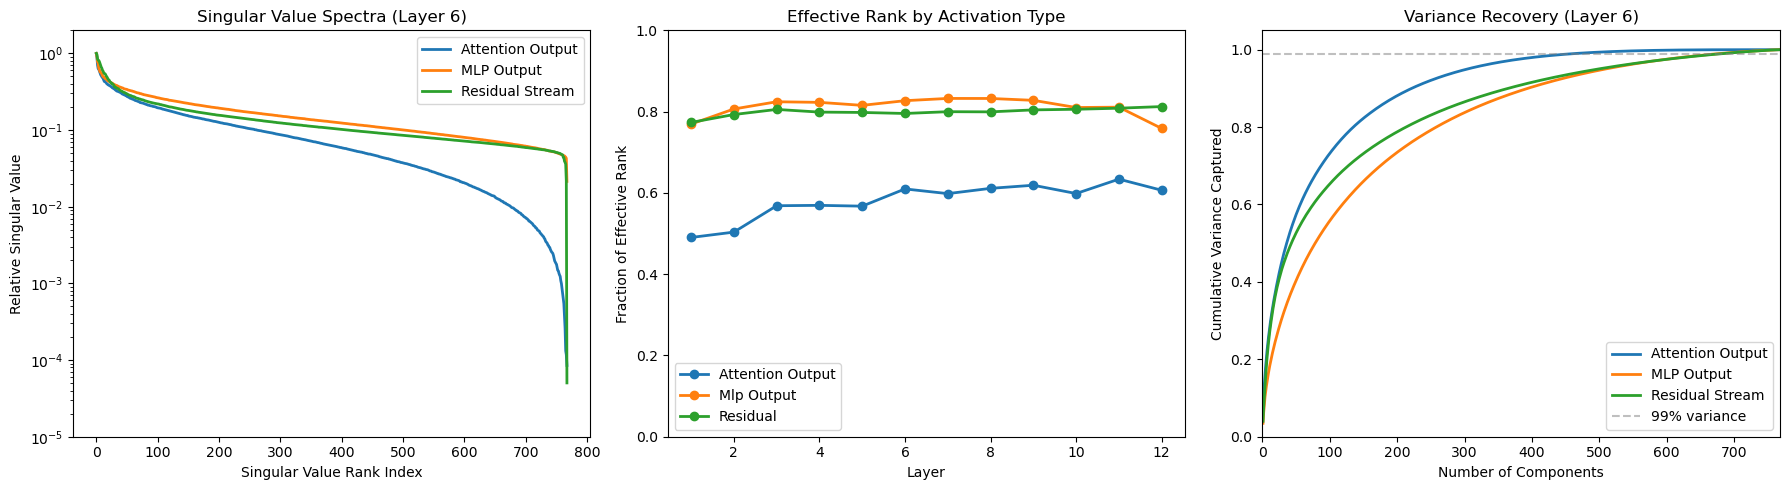


关键数值 (Layer 6):
  Attention Output    : dirs>1%=676/768 (88.0%), 99% var in 464/768 (60.4%)
  MLP Output          : dirs>1%=768/768 (100.0%), 99% var in 679/768 (88.4%)
  Residual Stream     : dirs>1%=767/768 (99.9%), 99% var in 684/768 (89.1%)


In [9]:
# 9. 谱衰减与有效维度对比 — 复现论文 Figure 3a
# 从已有 rank_metrics + subspaces 提取指标: attention_output vs MLP vs residual
import numpy as np
import matplotlib.pyplot as plt

try:
    completed_dir
except NameError:
    completed_dir = RUN_DIR

subspaces = np.load(completed_dir / 'analysis' / 'subspaces.npz', allow_pickle=False)
rank_metrics_full = pd.read_parquet(completed_dir / 'analysis' / 'rank_metrics.parquet')
rm = rank_metrics_full[rank_metrics_full['stream'] == 'token_natural_filtered'].copy()
rm_layers = rm[rm['layer'] > 0]

summary = rm_layers.groupby('kind').agg(
    effective_rank=('effective_rank', 'mean'),
    normalized_erank=('normalized_effective_rank', 'mean'),
    k90=('k90_variance', 'mean'),
    k95=('k95_variance', 'mean'),
    k99=('k99_variance', 'mean'),
    dirs_above_1pct=('directions_above_1pct_max', 'mean'),
    dimension=('dimension', 'first'),
).round(1)
display(summary)

layer = 6
sites = {
    'Attention Output': f'token_natural_filtered__attention_output_{layer:02d}',
    'MLP Output': f'token_natural_filtered__mlp_output_{layer:02d}',
    'Residual Stream': f'token_natural_filtered__residual_{layer:02d}',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 左: 奇异值谱 (Figure 3a)
ax = axes[0]
for label, prefix in sites.items():
    eigvals = subspaces[f'{prefix}__eigenvalues']
    sv = np.sqrt(np.maximum(eigvals, 0))
    rel_sv = sv / sv.max()
    ax.semilogy(range(len(rel_sv)), rel_sv, label=label, linewidth=2)
ax.set_xlabel('Singular Value Rank Index')
ax.set_ylabel('Relative Singular Value')
ax.set_title(f'Singular Value Spectra (Layer {layer})')
ax.legend()
ax.set_ylim(1e-5, 2)

# 中: 各层有效秩
ax = axes[1]
colors = {'attention_output': 'tab:blue', 'mlp_output': 'tab:orange', 'residual': 'tab:green'}
for kind in ['attention_output', 'mlp_output', 'residual']:
    sub_df = rm_layers[rm_layers['kind'] == kind].sort_values('layer')
    ax.plot(sub_df['layer'], sub_df['normalized_effective_rank'], 'o-',
            label=kind.replace('_', ' ').title(), color=colors[kind], linewidth=2)
ax.set_xlabel('Layer')
ax.set_ylabel('Fraction of Effective Rank')
ax.set_title('Effective Rank by Activation Type')
ax.legend()
ax.set_ylim(0, 1)

# 右: 累积方差恢复
ax = axes[2]
for label, prefix in sites.items():
    eigvals = np.maximum(subspaces[f'{prefix}__eigenvalues'], 0)
    cum = np.cumsum(eigvals) / eigvals.sum()
    ax.plot(range(1, len(cum) + 1), cum, label=label, linewidth=2)
ax.axhline(y=0.99, color='gray', linestyle='--', alpha=0.5, label='99% variance')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Variance Captured')
ax.set_title(f'Variance Recovery (Layer {layer})')
ax.legend()
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 768)

plt.tight_layout()
plt.show()

print(f'\n关键数值 (Layer {layer}):')
for label, prefix in sites.items():
    eigvals = np.maximum(subspaces[f'{prefix}__eigenvalues'], 0)
    sv = np.sqrt(eigvals)
    n_above_1pct = int((sv > 0.01 * sv.max()).sum())
    cum = np.cumsum(eigvals) / eigvals.sum()
    n_99 = int(np.searchsorted(cum, 0.99) + 1)
    dim = len(eigvals)
    print(f'  {label:20s}: dirs>1%={n_above_1pct}/{dim} ({100*n_above_1pct/dim:.1f}%), '
          f'99% var in {n_99}/{dim} ({100*n_99/dim:.1f}%)')

In [ ]:
# 10. 研报域单位置激活干预与 MLM-proxy 损失恢复
# 三类 activation 均只干预 Layer 6；PCA 样本与评估研报按 report_id/text hash 隔离。
# 该损失使用“微调 backbone + base-model MLM head”，不是 checkpoint 原训练目标。
from IPython.display import Image

from src.activation_rank_loss_recovery import run_loss_recovery_stage

LOSS_RECOVERY_POLICY = ROOT / 'configs' / 'activation_rank_loss_recovery.yaml'
loss_recovery_dir = run_loss_recovery_stage(config, LOSS_RECOVERY_POLICY)

loss_recovery_manifest = json.loads(
    (loss_recovery_dir / 'manifest.json').read_text(encoding='utf-8')
)
loss_recovery_summary = pd.read_parquet(loss_recovery_dir / 'site_summary.parquet')
loss_recovery_metrics = pd.read_parquet(
    loss_recovery_dir / 'loss_recovery_metrics.parquet'
)

display({
    'output': str(loss_recovery_dir),
    'loss_semantics': loss_recovery_manifest['loss_semantics'],
    'intervention_scope': loss_recovery_manifest['intervention_scope'],
    'evaluation_reports': loss_recovery_manifest['evaluation_reports'],
    'mask_seeds': loss_recovery_manifest['mask_seeds'],
    'pca_sample_report_overlap': loss_recovery_manifest['pca_sample_report_overlap'],
    'pca_sample_text_hash_overlap': loss_recovery_manifest['pca_sample_text_hash_overlap'],
})
display(loss_recovery_summary)
display(
    loss_recovery_metrics.loc[
        loss_recovery_metrics['n_components'].isin([0, 64, 128, 256, 384, 512, 768]),
        [
            'site', 'n_components', 'loss_original', 'loss_zero',
            'loss_projected', 'status', 'recovery_fraction',
            'recovery_ci_lower', 'recovery_ci_upper',
        ],
    ]
)
display(Image(filename=str(loss_recovery_dir / 'loss_recovery.png')))
